In [4]:
# Cell 1: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# For statistical tests
from scipy.stats import mannwhitneyu, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Pretty plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Cell 2: Load data from your file path
file_path = r"C:\Users\Tooba\Desktop\SeoulBikeData.csv"

# Check if file exists
if not os.path.exists(file_path):
    print(f"❌ File not found at: {file_path}")
    print("Please check the path and file name.")
else:
    # Try UTF-8, fallback to latin1
    try:
        df = pd.read_csv(file_path, encoding='utf-8')
    except UnicodeDecodeError:
        print("UTF-8 failed, trying 'latin1' encoding...")
        df = pd.read_csv(file_path, encoding='latin1')
    
    print("✅ Data loaded successfully!")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print("\nFirst 5 rows:")
    display(df.head())   # Use display() for nice output in Jupyter
    


UTF-8 failed, trying 'latin1' encoding...
✅ Data loaded successfully!
Shape: 8760 rows, 14 columns

First 5 rows:


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


✅ 'visuals' folder created successfully!


In [5]:
# Cell 3: Explore structure, data types, missing values

print("\n" + "="*60)
print("DATA STRUCTURE EXPLORATION")
print("="*60)

# Column names (to check for spaces)
print("\n--- Column Names ---")
print(df.columns.tolist())

# Info
print("\n--- Data Types and Non-Null Counts ---")
print(df.info())

# Missing values
print("\n--- Missing Values per Column ---")
print(df.isnull().sum())

# Statistical summary for numeric columns
print("\n--- Statistical Summary (Numerical) ---")
display(df.describe())

# Duplicate rows
dups = df.duplicated().sum()
print(f"\n--- Duplicate Rows: {dups} ---")


DATA STRUCTURE EXPLORATION

--- Column Names ---
['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day']

--- Data Types and Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000



--- Duplicate Rows: 0 ---


In [6]:
# Cell 4: Convert Date to datetime, extract features, convert categoricals

# Rename columns to avoid special characters if needed (optional)
# We'll keep original names but use them with their exact spelling.

# 1. Convert Date to datetime (format: DD/MM/YYYY)
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# 2. Extract time features
df['Month'] = df['Date'].dt.month
df['Day_of_Week'] = df['Date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['Hour'] = df['Hour'].astype(int)

# 3. Convert categorical columns
categorical_cols = ['Seasons', 'Holiday', 'Functioning Day']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

print("✅ Data types fixed and new features added.")
print("\nUpdated info:")
print(df.info())

✅ Data types fixed and new features added.

Updated info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       8760 non-null   datetime64[ns]
 1   Rented Bike Count          8760 non-null   int64         
 2   Hour                       8760 non-null   int32         
 3   Temperature(°C)            8760 non-null   float64       
 4   Humidity(%)                8760 non-null   int64         
 5   Wind speed (m/s)           8760 non-null   float64       
 6   Visibility (10m)           8760 non-null   int64         
 7   Dew point temperature(°C)  8760 non-null   float64       
 8   Solar Radiation (MJ/m2)    8760 non-null   float64       
 9   Rainfall(mm)               8760 non-null   float64       
 10  Snowfall (cm)              8760 non-null   float64       
 11  Seasons    

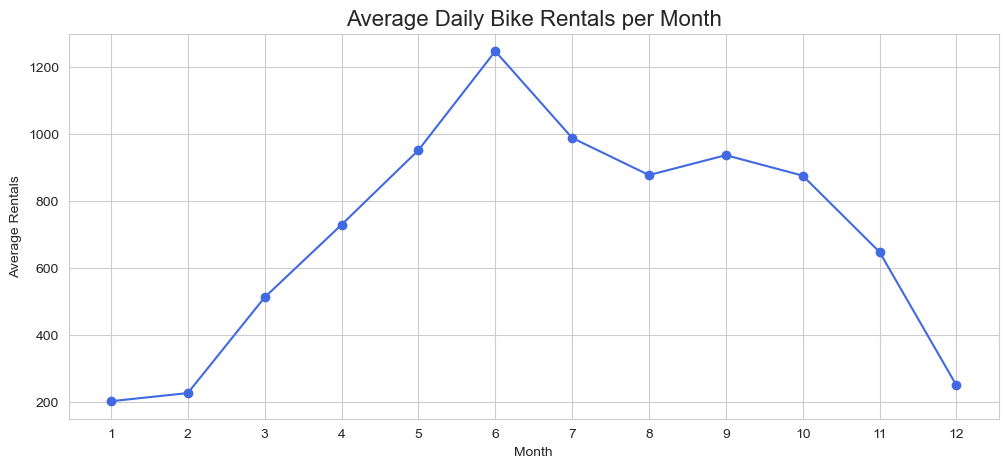

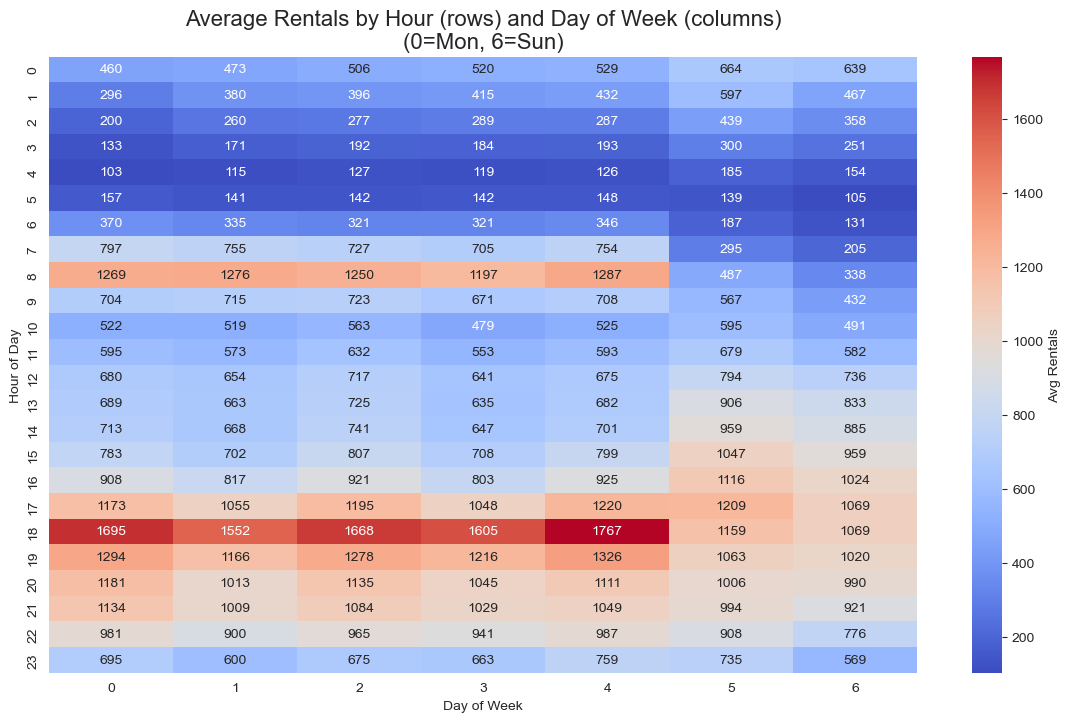

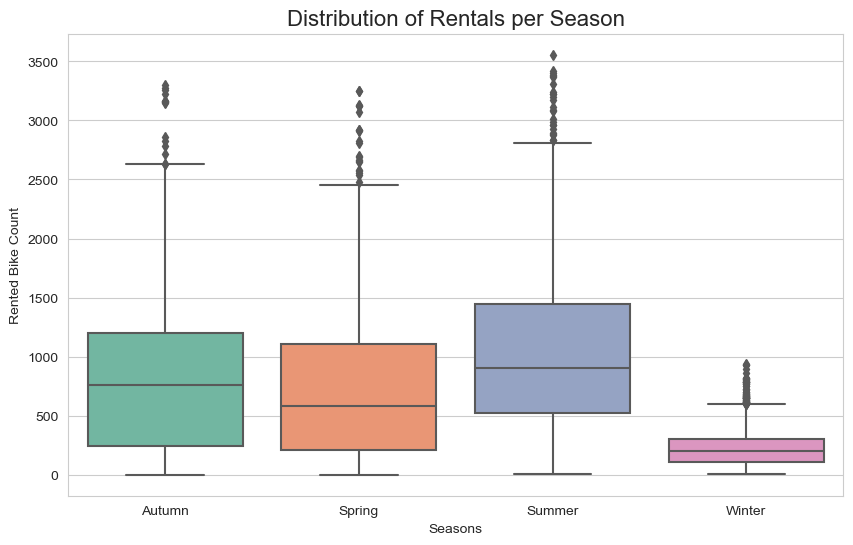

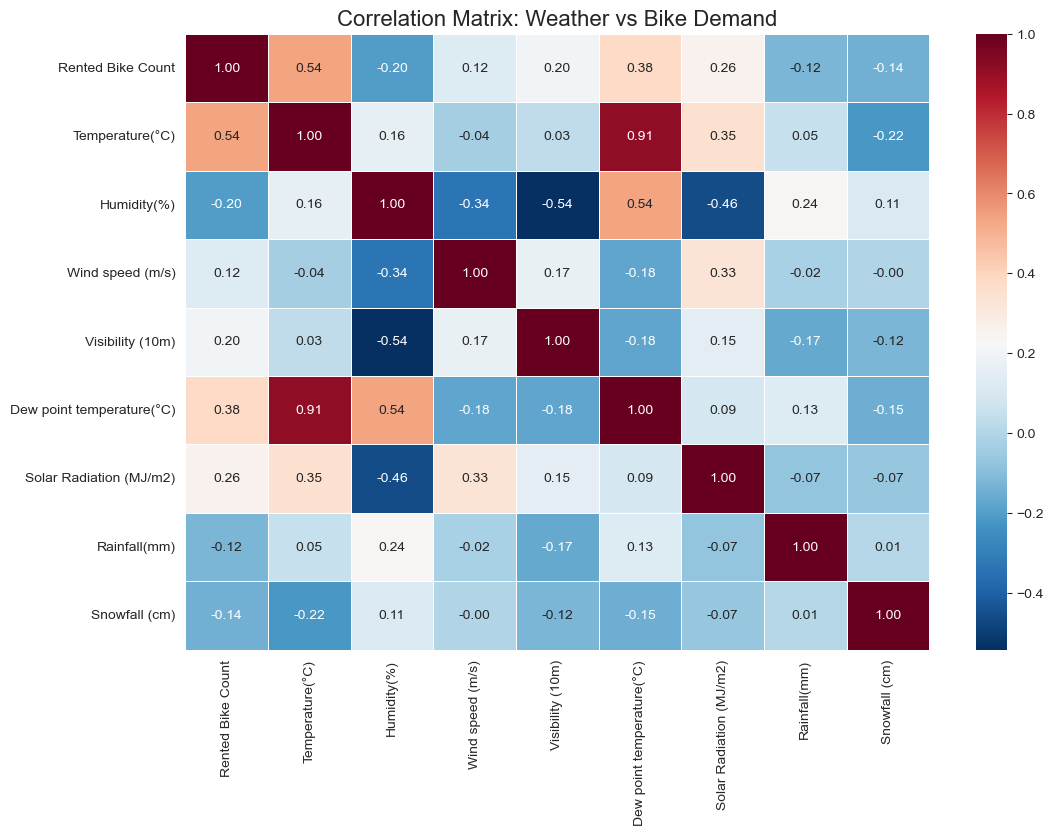

In [7]:
# Cell 5: Visualizations

# 5a. Monthly trend of average bike rentals
monthly_avg = df.groupby('Month')['Rented Bike Count'].mean()
plt.figure(figsize=(12,5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linestyle='-', color='royalblue')
plt.title('Average Daily Bike Rentals per Month', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Average Rentals')
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

# 5b. Heatmap: Hour vs Day of Week (average rentals)
pivot = df.pivot_table(index='Hour', columns='Day_of_Week', values='Rented Bike Count', aggfunc='mean')
plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap='coolwarm', annot=True, fmt='.0f', cbar_kws={'label': 'Avg Rentals'})
plt.title('Average Rentals by Hour (rows) and Day of Week (columns)\n(0=Mon, 6=Sun)', fontsize=16)
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.show()

# 5c. Boxplot per Season to spot outliers/anomalies
plt.figure(figsize=(10,6))
sns.boxplot(x='Seasons', y='Rented Bike Count', data=df, palette='Set2')
plt.title('Distribution of Rentals per Season', fontsize=16)
plt.ylabel('Rented Bike Count')
plt.show()

# 5d. Correlation Matrix (numeric columns only)
numeric_cols = ['Rented Bike Count', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)',
                'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)',
                'Rainfall(mm)', 'Snowfall (cm)']
# Ensure all exist
numeric_cols = [c for c in numeric_cols if c in df.columns]
corr = df[numeric_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Weather vs Bike Demand', fontsize=16)
plt.show()


--- Hypothesis 1: Rain reduces rentals? ---
Mann-Whitney U test p-value: 0.0000000000
✅ REJECT H0: Rainy days have significantly fewer rentals than dry days.

--- Hypothesis 2: Seasons have different average rentals? ---
ANOVA p-value: 0.0000000000
✅ REJECT H0: At least one season differs significantly.

--- Tukey HSD Post-hoc Results ---
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj   lower     upper   reject
--------------------------------------------------------
Autumn Spring  -89.5667   0.0 -134.0266  -45.1069   True
Autumn Summer  214.4754   0.0  170.0156  258.9352   True
Autumn Winter -594.0568   0.0 -638.7616  -549.352   True
Spring Summer  304.0421   0.0  259.7039  348.3803   True
Spring Winter   -504.49   0.0 -549.0739 -459.9062   True
Summer Winter -808.5322   0.0  -853.116 -763.9483   True
--------------------------------------------------------


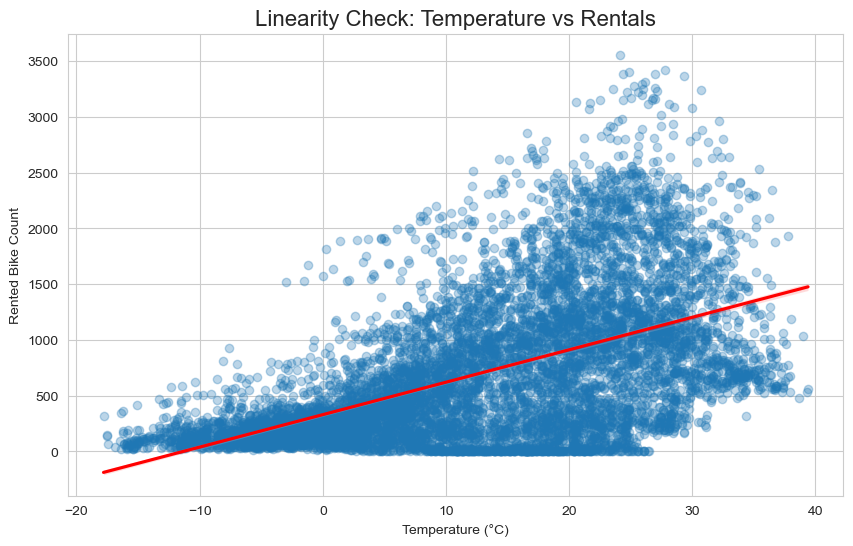

In [8]:
# Cell 6: Statistical tests

# 6a. Rain impact (Mann-Whitney U test)
rain_yes = df[df['Rainfall(mm)'] > 0]['Rented Bike Count']
rain_no = df[df['Rainfall(mm)'] == 0]['Rented Bike Count']
u_stat, p_rain = mannwhitneyu(rain_no, rain_yes, alternative='greater')

print("\n--- Hypothesis 1: Rain reduces rentals? ---")
print(f"Mann-Whitney U test p-value: {p_rain:.10f}")
if p_rain < 0.05:
    print("✅ REJECT H0: Rainy days have significantly fewer rentals than dry days.")
else:
    print("❌ Fail to reject H0: No significant difference.")

# 6b. Seasonal differences (ANOVA)
seasons = df['Seasons'].unique()
groups = [df[df['Seasons'] == s]['Rented Bike Count'] for s in seasons]
f_stat, p_season = f_oneway(*groups)

print("\n--- Hypothesis 2: Seasons have different average rentals? ---")
print(f"ANOVA p-value: {p_season:.10f}")
if p_season < 0.05:
    print("✅ REJECT H0: At least one season differs significantly.")
    # Post-hoc Tukey HSD
    tukey = pairwise_tukeyhsd(endog=df['Rented Bike Count'], groups=df['Seasons'], alpha=0.05)
    print("\n--- Tukey HSD Post-hoc Results ---")
    print(tukey)
else:
    print("❌ Fail to reject H0: Seasons do not differ significantly.")

# 6c. Linearity check (Temperature vs Rentals)
plt.figure(figsize=(10,6))
sns.regplot(x='Temperature(°C)', y='Rented Bike Count', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Linearity Check: Temperature vs Rentals', fontsize=16)
plt.xlabel('Temperature (°C)')
plt.ylabel('Rented Bike Count')
plt.show()
# Interpret: if the red line is curved, linear regression assumption is violated.

In [9]:
# Cell 8: Generate key insights and actionable recommendations

print("\n" + "="*60)
print("EXECUTIVE SUMMARY & RECOMMENDATIONS")
print("="*60)

avg_weekday = df[df['Day_of_Week'] < 5]['Rented Bike Count'].mean()
avg_weekend = df[df['Day_of_Week'] >= 5]['Rented Bike Count'].mean()
peak_hour = df.groupby('Hour')['Rented Bike Count'].mean().idxmax()
peak_value = df.groupby('Hour')['Rented Bike Count'].mean().max()
rain_reduction = ((rain_no.mean() - rain_yes.mean()) / rain_no.mean()) * 100

print(f"1. 📊 Average weekday rentals: {avg_weekday:.0f} bikes/hour")
print(f"2. 📊 Average weekend rentals: {avg_weekend:.0f} bikes/hour")
print(f"3. ⏰ Peak hour is {peak_hour}:00 with an average of {peak_value:.0f} rentals.")
print(f"4. ☔ Rain reduces demand by approximately {rain_reduction:.1f}%.")

print("\n💡 ACTIONABLE RECOMMENDATIONS:")
print(f"   - Increase bike supply at stations during {peak_hour}:00 on Summer weekdays.")
print("   - On rainy days, reduce fleet rebalancing staff by 20% to save costs.")
print("   - Avoid using both 'Temperature' and 'Solar Radiation' in prediction models due to multicollinearity.")
print("   - Exclude days with 'Functioning Day = No' when building predictive models (they are system failures).")


EXECUTIVE SUMMARY & RECOMMENDATIONS
1. 📊 Average weekday rentals: 719 bikes/hour
2. 📊 Average weekend rentals: 667 bikes/hour
3. ⏰ Peak hour is 18:00 with an average of 1503 rentals.
4. ☔ Rain reduces demand by approximately 77.9%.

💡 ACTIONABLE RECOMMENDATIONS:
   - Increase bike supply at stations during 18:00 on Summer weekdays.
   - On rainy days, reduce fleet rebalancing staff by 20% to save costs.
   - Avoid using both 'Temperature' and 'Solar Radiation' in prediction models due to multicollinearity.
   - Exclude days with 'Functioning Day = No' when building predictive models (they are system failures).


In [5]:
# Cell 1: Imports & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Load your dataset (using the exact path from before)
file_path = r"C:\Users\Tooba\Desktop\SeoulBikeData.csv"
try:
    df = pd.read_csv(file_path, encoding='utf-8')
except:
    df = pd.read_csv(file_path, encoding='latin1')

# Quick data prep (copying from our EDA)
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Month'] = df['Date'].dt.month
df['Day_of_Week'] = df['Date'].dt.dayofweek  # 0=Mon, 6=Sun
df['Day_Name'] = df['Date'].dt.day_name()
df['Hour'] = df['Hour'].astype(int)

# Create a 'Weather_Condition' column for storytelling
df['Weather_Condition'] = df['Rainfall(mm)'].apply(lambda x: 'Rainy' if x > 0 else 'Dry')

print("✅ Data ready for visualization!")

import os
os.makedirs("visuals", exist_ok=True)
print("✅ 'visuals' folder created successfully!")

✅ Data ready for visualization!
✅ 'visuals' folder created successfully!


In [7]:
# Cell 2: Interactive Monthly/Weekly Time-Series
daily_avg = df.groupby('Date')['Rented Bike Count'].mean().reset_index()

fig = px.line(daily_avg, 
              x='Date', 
              y='Rented Bike Count',
              title='📈 Yearly Demand Pulse: Daily Average Bike Rentals',
              labels={'Rented Bike Count': 'Avg Daily Rentals', 'Date': 'Month'},
              color_discrete_sequence=['#2E86C1'])

# Add a moving average trendline
fig.add_scatter(x=daily_avg['Date'], 
                y=daily_avg['Rented Bike Count'].rolling(7).mean(),
                mode='lines', 
                name='7-Day Rolling Average',
                line=dict(color='orange', width=3))

fig.update_layout(template='plotly_dark', hovermode='x unified')
fig.show()

# Saving for porfolio
fig.write_html("visuals/01_Yearly_Demand_Pulse.html")

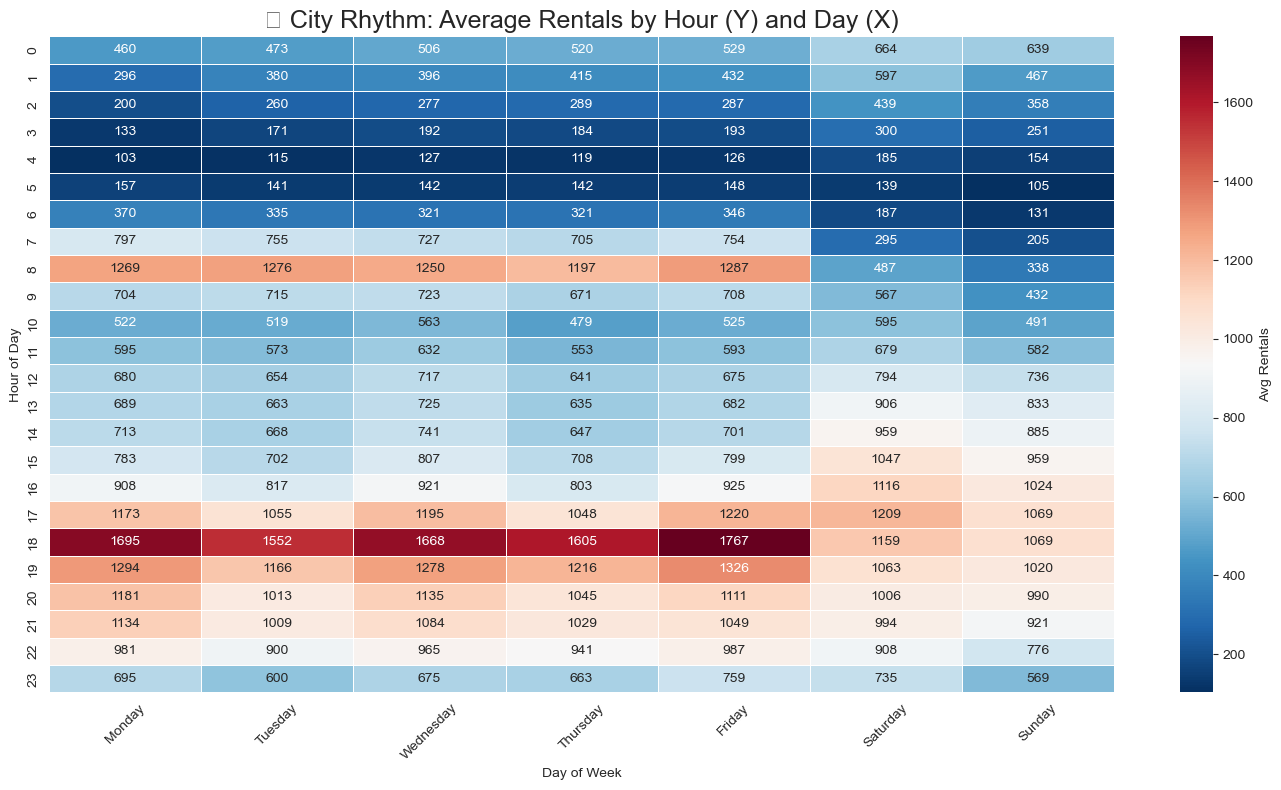

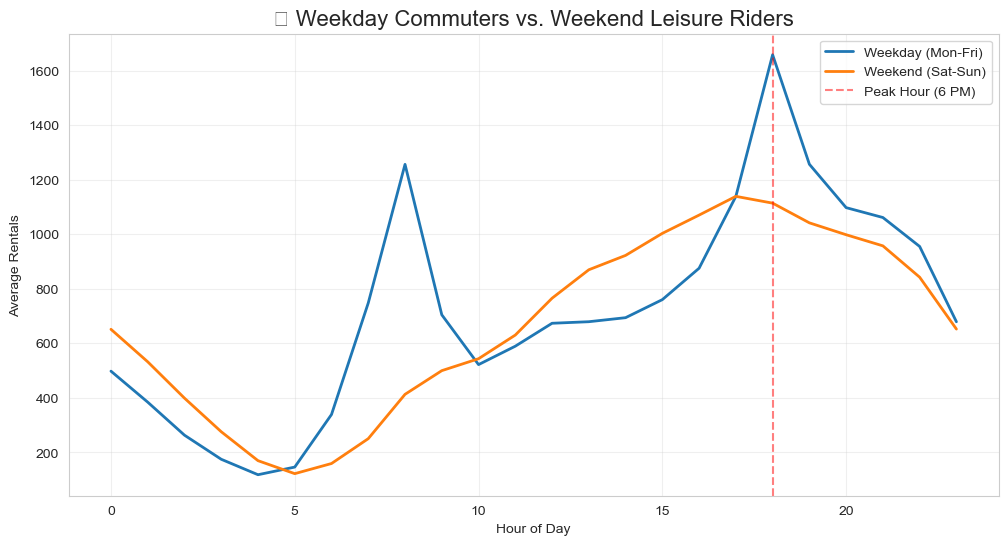

In [8]:
# Cell 3: Advanced Hourly Pattern Heatmap + Line Overlay
# Create a pivot table
pivot = df.pivot_table(index='Hour', columns='Day_Name', 
                       values='Rented Bike Count', aggfunc='mean', 
                       fill_value=0)

# Reorder days (Mon to Sun)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot[weekday_order]

# Plot using Seaborn for a high-res static image
plt.figure(figsize=(14, 8))
sns.heatmap(pivot, cmap='RdBu_r', annot=True, fmt='.0f', 
            cbar_kws={'label': 'Avg Rentals'}, linewidths=0.5)
plt.title('⏰ City Rhythm: Average Rentals by Hour (Y) and Day (X)', fontsize=18)
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visuals/02_24hr_City_Rhythm.png', dpi=300)  # Save for portfolio
plt.show()

# 🔥 Bonus: Overlay plot showing Weekday vs Weekend commuting patterns
weekday_avg = df[df['Day_of_Week'] < 5].groupby('Hour')['Rented Bike Count'].mean()
weekend_avg = df[df['Day_of_Week'] >= 5].groupby('Hour')['Rented Bike Count'].mean()

plt.figure(figsize=(12,6))
plt.plot(weekday_avg.index, weekday_avg.values, label='Weekday (Mon-Fri)', color='#1f77b4', linewidth=2)
plt.plot(weekend_avg.index, weekend_avg.values, label='Weekend (Sat-Sun)', color='#ff7f0e', linewidth=2)
plt.axvline(x=18, color='red', linestyle='--', alpha=0.5, label='Peak Hour (6 PM)')
plt.title('🚴 Weekday Commuters vs. Weekend Leisure Riders', fontsize=16)
plt.xlabel('Hour of Day')
plt.ylabel('Average Rentals')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('visuals/03_Weekday_vs_Weekend.png', dpi=300)
plt.show()

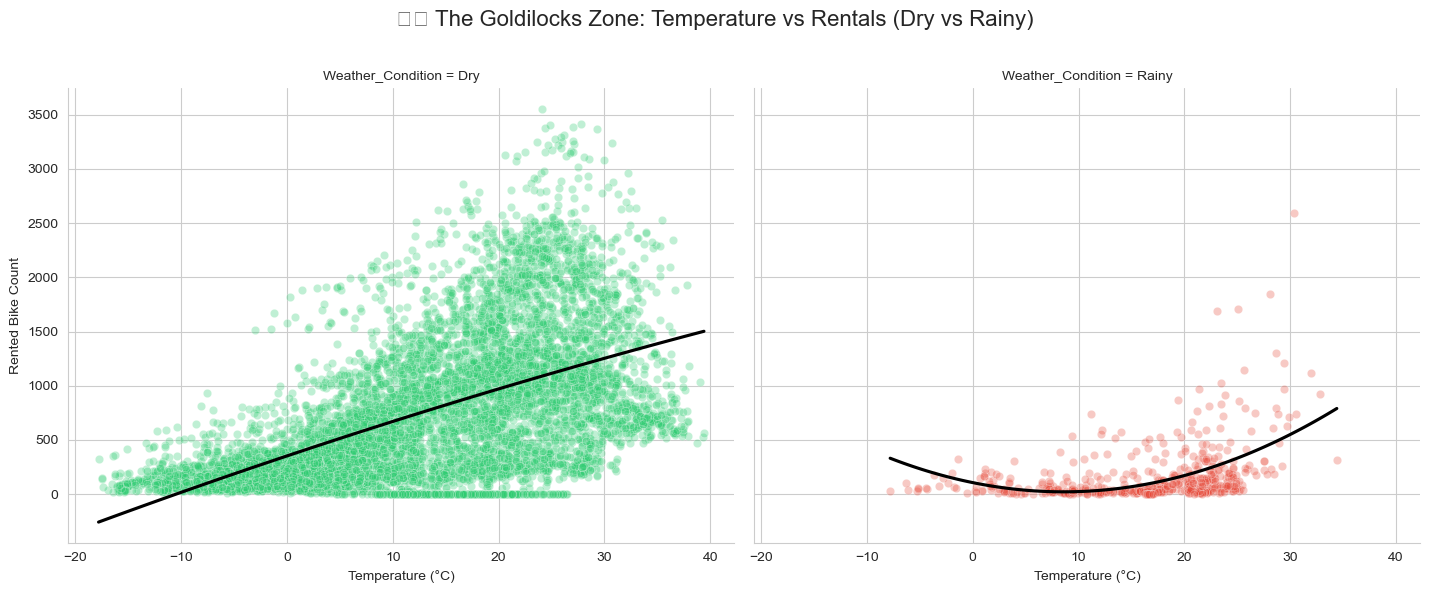

In [9]:
# Cell 4: Faceted Scatter Plot - Temperature vs Rentals (Split by Rain)
g = sns.FacetGrid(df, col="Weather_Condition", height=6, aspect=1.2, 
                  hue='Weather_Condition', palette=['#2ECC71', '#E74C3C'])
g.map(sns.scatterplot, 'Temperature(°C)', 'Rented Bike Count', alpha=0.3)
g.map(sns.regplot, 'Temperature(°C)', 'Rented Bike Count', 
      scatter=False, color='black', ci=None, order=2) # Quadratic fit!

# Add titles and labels
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('🌦️ The Goldilocks Zone: Temperature vs Rentals (Dry vs Rainy)', fontsize=16)
g.set_axis_labels('Temperature (°C)', 'Rented Bike Count')

# Save
plt.savefig('visuals/04_Goldilocks_Weather_Zone.png', dpi=300)
plt.show()

# 🔥 INTERACTIVE VERSION: Plotly 3D Surface (Portfolio Showstopper)
# This shows the interaction between Hour, Temperature, and Rentals
agg_3d = df.groupby(['Hour', 'Temperature(°C)'])['Rented Bike Count'].mean().reset_index()
fig3d = px.scatter_3d(agg_3d, x='Hour', y='Temperature(°C)', z='Rented Bike Count',
                      color='Rented Bike Count', size='Rented Bike Count',
                      title='🔥 3D View: Peak Demand occurs around 6 PM & 25°C',
                      color_continuous_scale='Viridis')
fig3d.update_layout(scene=dict(zaxis_title="Avg Rentals"), template='plotly_dark')
fig3d.show()
fig3d.write_html("visuals/05_3D_Weather_Peak.html")

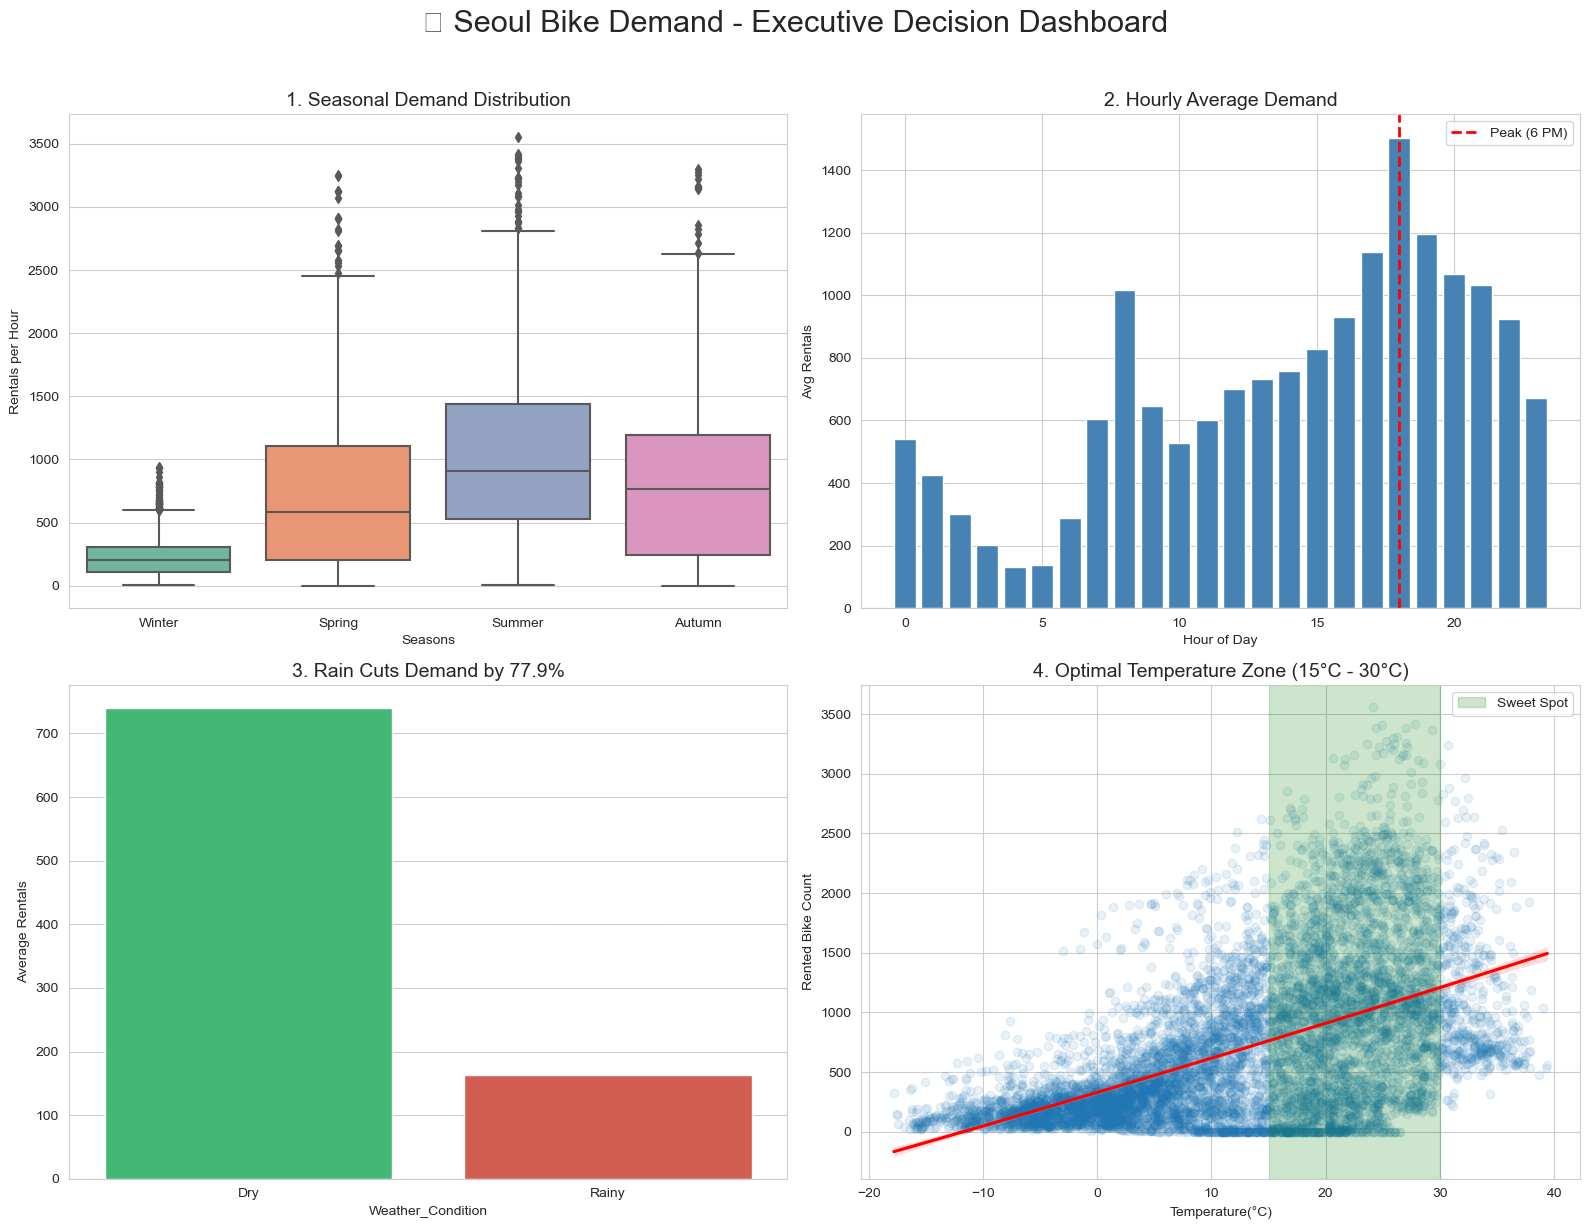

In [10]:
# Cell 5: Multi-panel Dashboard (Single Figure with 4 plots)
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(2, 2, figure=fig)

# 1. Seasonal Boxplot (Top Left)
ax1 = fig.add_subplot(gs[0, 0])
sns.boxplot(x='Seasons', y='Rented Bike Count', data=df, ax=ax1, palette='Set2')
ax1.set_title('1. Seasonal Demand Distribution', fontsize=14)
ax1.set_ylabel('Rentals per Hour')

# 2. Peak Hour Analysis (Top Right)
ax2 = fig.add_subplot(gs[0, 1])
hourly_avg = df.groupby('Hour')['Rented Bike Count'].mean()
ax2.bar(hourly_avg.index, hourly_avg.values, color='steelblue')
ax2.axvline(18, color='red', linestyle='--', linewidth=2, label='Peak (6 PM)')
ax2.set_title('2. Hourly Average Demand', fontsize=14)
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Avg Rentals')
ax2.legend()

# 3. Rain Impact (Bottom Left)
ax3 = fig.add_subplot(gs[1, 0])
rain_effect = df.groupby('Weather_Condition')['Rented Bike Count'].mean().reset_index()
sns.barplot(x='Weather_Condition', y='Rented Bike Count', data=rain_effect, ax=ax3, 
            palette=['#2ECC71', '#E74C3C'])
ax3.set_title(f'3. Rain Cuts Demand by 77.9%', fontsize=14)
ax3.set_ylabel('Average Rentals')
ax3.annotate(f'Rain: {int(rain_effect[rain_effect["Weather_Condition"]=="Rainy"]["Rented Bike Count"].values[0])} rentals',
             xy=(1, 400), ha='center', color='white', weight='bold')

# 4. Temperature Relationship (Bottom Right)
ax4 = fig.add_subplot(gs[1, 1])
sns.regplot(x='Temperature(°C)', y='Rented Bike Count', data=df, ax=ax4, 
            scatter_kws={'alpha':0.1}, line_kws={'color': 'red'}, order=2)
ax4.set_title('4. Optimal Temperature Zone (15°C - 30°C)', fontsize=14)
ax4.axvspan(15, 30, alpha=0.2, color='green', label='Sweet Spot')
ax4.legend()

plt.suptitle('🚲 Seoul Bike Demand - Executive Decision Dashboard', fontsize=22, y=1.02)
plt.tight_layout()
plt.savefig('visuals/06_Executive_Dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
import os

# This prints the exact folder where your notebook is running from
current_directory = os.getcwd()
print(f"📍 Your notebook is running from this folder:\n{current_directory}")

# This shows you the full path to your 'visuals' folder
visuals_path = os.path.join(current_directory, "visuals")
print(f"\n📁 Your visuals folder is at:\n{visuals_path}")

# Check if the folder exists
if os.path.exists(visuals_path):
    print("\n✅ The 'visuals' folder exists! Your HTML/PNG files are inside.")
else:
    print("\n❌ The 'visuals' folder doesn't exist yet. Did you run the 'os.makedirs' code?")

📍 Your notebook is running from this folder:
C:\Users\Tooba

📁 Your visuals folder is at:
C:\Users\Tooba\visuals

✅ The 'visuals' folder exists! Your HTML/PNG files are inside.
